# Mathematical Induction

Many statements in discrete mathematics claim that something is true for *every* positive integer $n$ — for example, "the sum of the first $n$ positive integers is $\frac{n(n+1)}{2}$." We cannot check infinitely many cases one at a time. **Mathematical induction** is a proof technique built exactly for these "for all $n$" statements.

Before we get to induction, here is a quick map of the common **methods of proof**.

## Methods of Proof

Suppose we want to prove an implication $p \rightarrow q$ ("if $p$, then $q$").

- **Direct proof.** Assume $p$ is true and use definitions and known facts to derive $q$.
- **Proof by contraposition.** Instead of $p \rightarrow q$, prove the logically equivalent statement $\lnot q \rightarrow \lnot p$.
- **Proof by contradiction.** Assume the statement is *false*, then derive a contradiction (something that cannot possibly hold). Since assuming falsehood leads to nonsense, the statement must be true.

**Mathematical induction** is a fourth technique, used specifically to prove that a statement $P(n)$ holds for *all* integers $n$ at or above some starting value.

## The Principle of Mathematical Induction

To prove that a statement $P(n)$ is true for every integer $n \ge n_0$ (often $n_0 = 0$ or $1$), we complete two steps:

1. **Basis step (base case).** Show that $P(n_0)$ is true.
2. **Inductive step.** Show that *for every* $k \ge n_0$, **if** $P(k)$ is true **then** $P(k+1)$ is true. The assumption "$P(k)$ is true" is called the **inductive hypothesis**.

If both steps succeed, then $P(n)$ is true for all $n \ge n_0$.

Think of it like a line of dominoes: the basis step tips over the first domino, and the inductive step guarantees that each domino knocks over the next — so every domino falls.

## Example 1: Sum of the First $n$ Positive Integers

**Claim.** For all $n \ge 1$, $\displaystyle\sum_{i=1}^{n} i = 1 + 2 + \cdots + n = \frac{n(n+1)}{2}$.

**Proof by induction.**

*Basis step* ($n=1$): the left side is $1$, and the right side is $\frac{1(1+1)}{2} = 1$. They agree, so $P(1)$ holds.

*Inductive step:* assume $P(k)$ holds for some $k \ge 1$, i.e. $\sum_{i=1}^{k} i = \frac{k(k+1)}{2}$ (the inductive hypothesis). Then

$$\sum_{i=1}^{k+1} i = \left(\sum_{i=1}^{k} i\right) + (k+1) = \frac{k(k+1)}{2} + (k+1) = \frac{k(k+1) + 2(k+1)}{2} = \frac{(k+1)(k+2)}{2}.$$

This is exactly $P(k+1)$. By the principle of mathematical induction, the formula holds for all $n \ge 1$. $\blacksquare$

In [1]:
def lhs(n):
    return sum(range(1, n + 1))

def rhs(n):
    return n * (n + 1) // 2

# Check the identity for the first 20 values of n.
print("sum 1..n == n(n+1)/2 for n = 1..20:", all(lhs(n) == rhs(n) for n in range(1, 21)))
for n in [1, 2, 5, 10, 100]:
    print(f"n={n:>3}:  sum={lhs(n):>5}   n(n+1)/2={rhs(n):>5}")

sum 1..n == n(n+1)/2 for n = 1..20: True
n=  1:  sum=    1   n(n+1)/2=    1
n=  2:  sum=    3   n(n+1)/2=    3
n=  5:  sum=   15   n(n+1)/2=   15
n= 10:  sum=   55   n(n+1)/2=   55
n=100:  sum= 5050   n(n+1)/2= 5050


## Example 2: Sum of the First $n$ Odd Numbers

**Claim.** For all $n \ge 1$, $1 + 3 + 5 + \cdots + (2n-1) = n^2$.

**Proof.**

*Basis step* ($n=1$): the left side is $1$ and the right side is $1^2 = 1$. ✓

*Inductive step:* assume $1 + 3 + \cdots + (2k-1) = k^2$. The next odd number is $2(k+1)-1 = 2k+1$, so

$$\big(1 + 3 + \cdots + (2k-1)\big) + (2k+1) = k^2 + 2k + 1 = (k+1)^2.$$

That is $P(k+1)$, which completes the induction. $\blacksquare$

n          : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
sum of odds: [1, 4, 9, 16, 25, 36, 49, 64, 81, 100]
n^2        : [1, 4, 9, 16, 25, 36, 49, 64, 81, 100]


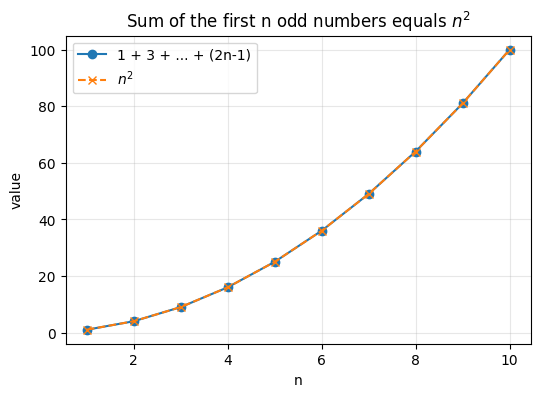

In [2]:
import matplotlib.pyplot as plt

def odd_sum(n):
    return sum(2 * i - 1 for i in range(1, n + 1))

ns = list(range(1, 11))
partial = [odd_sum(n) for n in ns]
squares = [n ** 2 for n in ns]

print("n          :", ns)
print("sum of odds:", partial)
print("n^2        :", squares)

plt.figure(figsize=(6, 4))
plt.plot(ns, partial, "o-", label="1 + 3 + ... + (2n-1)")
plt.plot(ns, squares, "x--", label="$n^2$")
plt.xlabel("n")
plt.ylabel("value")
plt.title("Sum of the first n odd numbers equals $n^2$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Example 3: A Divisibility Result

**Claim.** For all $n \ge 0$, $n^3 - n$ is divisible by $3$.

**Proof.**

*Basis step* ($n=0$): $0^3 - 0 = 0 = 3 \cdot 0$, which is divisible by $3$. ✓

*Inductive step:* assume $3 \mid (k^3 - k)$, say $k^3 - k = 3m$ for some integer $m$. Then

$$(k+1)^3 - (k+1) = k^3 + 3k^2 + 3k + 1 - k - 1 = (k^3 - k) + 3k^2 + 3k = 3m + 3(k^2 + k) = 3\big(m + k^2 + k\big),$$

which is a multiple of $3$. So $3 \mid \big((k+1)^3 - (k+1)\big)$, and by induction the result holds for all $n \ge 0$. $\blacksquare$

In [3]:
def divisible_by_3(n):
    return (n**3 - n) % 3 == 0

print("n^3 - n divisible by 3 for n = 0..30:", all(divisible_by_3(n) for n in range(31)))
for n in range(7):
    print(f"n={n}:  n^3 - n = {n**3 - n:>3}  =  3 * {(n**3 - n)//3}")

n^3 - n divisible by 3 for n = 0..30: True
n=0:  n^3 - n =   0  =  3 * 0
n=1:  n^3 - n =   0  =  3 * 0
n=2:  n^3 - n =   6  =  3 * 2
n=3:  n^3 - n =  24  =  3 * 8
n=4:  n^3 - n =  60  =  3 * 20
n=5:  n^3 - n = 120  =  3 * 40
n=6:  n^3 - n = 210  =  3 * 70


## Example 4: An Inequality

**Claim.** For all integers $n \ge 1$, $2^n > n$.

**Proof.**

*Basis step* ($n=1$): $2^1 = 2 > 1$. ✓

*Inductive step:* assume $2^k > k$ for some $k \ge 1$. Then

$$2^{k+1} = 2 \cdot 2^k > 2k = k + k \ge k + 1,$$

where the final step uses $k \ge 1$. Hence $2^{k+1} > k+1$, which is $P(k+1)$. By induction, $2^n > n$ for all $n \ge 1$. $\blacksquare$

2^n > n for n = 1..1000: True


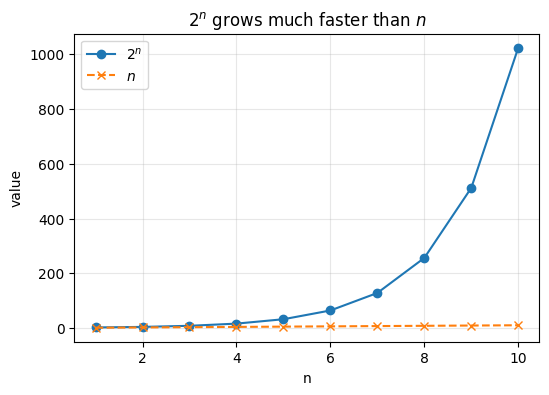

In [4]:
import matplotlib.pyplot as plt

print("2^n > n for n = 1..1000:", all(2**n > n for n in range(1, 1001)))

ns = list(range(1, 11))
powers = [2**n for n in ns]

plt.figure(figsize=(6, 4))
plt.plot(ns, powers, "o-", label="$2^n$")
plt.plot(ns, ns, "x--", label="$n$")
plt.xlabel("n")
plt.ylabel("value")
plt.title("$2^n$ grows much faster than $n$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Strong Induction

Sometimes proving $P(k+1)$ needs more than just $P(k)$ — it may rely on several (or all) of the earlier cases $P(n_0), \dots, P(k)$. **Strong induction** allows exactly that: in the inductive step you may assume $P(j)$ holds for *all* $j$ with $n_0 \le j \le k$.

**Example.** *Every integer $n \ge 2$ can be written as a product of one or more primes.*

*Basis step* ($n=2$): $2$ is prime, so it is a (single-factor) product of primes. ✓

*Inductive step:* assume every integer $j$ with $2 \le j \le k$ is a product of primes. Consider $k+1$.

- If $k+1$ is prime, it is already a product of primes.
- If $k+1$ is composite, then $k+1 = a \cdot b$ with $2 \le a, b \le k$. By the strong inductive hypothesis, both $a$ and $b$ are products of primes, so their product $k+1$ is too.

By strong induction, every integer $n \ge 2$ is a product of primes — the existence half of the **Fundamental Theorem of Arithmetic**. $\blacksquare$

In [5]:
def prime_factors(n):
    """Return the list of prime factors of n (n >= 2), smallest first."""
    factors = []
    d = 2
    while d * d <= n:
        while n % d == 0:
            factors.append(d)
            n //= d
        d += 1
    if n > 1:
        factors.append(n)
    return factors

for n in [2, 12, 17, 60, 100, 360]:
    fs = prime_factors(n)
    product = 1
    for f in fs:
        product *= f
    print(f"{n:>3} = {' * '.join(map(str, fs)):<15}  (check: product = {product})")

  2 = 2                (check: product = 2)
 12 = 2 * 2 * 3        (check: product = 12)
 17 = 17               (check: product = 17)
 60 = 2 * 2 * 3 * 5    (check: product = 60)
100 = 2 * 2 * 5 * 5    (check: product = 100)
360 = 2 * 2 * 2 * 3 * 3 * 5  (check: product = 360)


## Mathematical Induction Practice Problems

Write your Python in the code cell beneath each problem (some starter code is provided). Worked solutions are in [`solutions/07_mathematical_induction_key.ipynb`](solutions/07_mathematical_induction_key.ipynb).

### Problem 1: Sum of Squares

Verify computationally that $\sum_{i=1}^{n} i^2 = \dfrac{n(n+1)(2n+1)}{6}$ for all $n$ from 1 to 20. (Then you would prove it by induction.)

In [6]:
# Compare the direct sum to the closed-form formula for n = 1..20.
# WRITE YOUR CODE BELOW


### Problem 2: Sum of Even Numbers

Verify that $\sum_{i=1}^{n} 2i = n(n+1)$ for $n = 1$ to $20$.

In [7]:
# WRITE YOUR CODE BELOW


### Problem 3: A Parity Result

Verify that $n^2 + n$ is even for every integer $n$ from 0 to 30.

In [8]:
# WRITE YOUR CODE BELOW


### Problem 4: Geometric Sum of Powers of 2

Verify that $1 + 2 + 4 + \cdots + 2^{n-1} = 2^n - 1$ for $n = 1$ to $15$.

In [9]:
# WRITE YOUR CODE BELOW
